In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
# Get the parent directory
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [2]:
model = 'PSPL'
# model = 'FSPL'
path= parent_directory+f'/all_results/{model}_last/'

In [4]:
fit_rr = pd.read_parquet(path+"/fit_rr.parquet")
fit_roman =  pd.read_parquet(path+"/fit_roman.parquet")
true = pd.read_parquet(path+"/true.parquet")

roman_detected = true['W149_peak'] != 0
rubin_detected = (
    (true['u_peak'] != 0) |
    (true['g_peak'] != 0) |
    (true['r_peak'] != 0) |
    (true['i_peak'] != 0) |
    (true['z_peak'] != 0) |
    (true['y_peak'] != 0)
)

# Define categories using boolean masks
cat_A_mask = roman_detected & rubin_detected
cat_B_mask = ~roman_detected & rubin_detected
cat_C_mask = roman_detected & ~rubin_detected
cat_D_mask = ~roman_detected & ~rubin_detected

# Assign flags
conditions = [cat_A_mask, cat_B_mask, cat_C_mask, cat_D_mask]
choices = ['A', 'B', 'C', 'D']
true['peak_flag'] = np.select(conditions, choices, default=None)
mask_relevant_event = roman_detected|rubin_detected
true["flag_relevance"] = mask_relevant_event

condition = (
    (true['W149_npeak'] +
     true['u_npeak'] +
     true['g_npeak'] +
     true['r_npeak'] +
     true['i_npeak'] +
     true['z_npeak'] +
     true['y_npeak']) > 10
)

true['flag_npeak_gt10'] = condition.astype(int)
true_filtered = true[true['flag_npeak_gt10']==1]
fit_rr_filtered = fit_rr.merge(true_filtered[['Source', 'Set']], on=['Source', 'Set'], how='inner')
fit_roman_filtered = fit_roman.merge(true_filtered[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met_1_rr, met_2_rr, met_3_rr = metrics_creator(true_filtered,fit_rr_filtered, model)
met_1_roman, met_2_roman, met_3_roman = metrics_creator(true_filtered,fit_roman_filtered, model)


Filas después del merge: 119762
Filas después del merge: 119762


In [5]:
# ¿Cuántas filas tienen problemas en algún parámetro?
problemas = met_1_rr[met_1_rr['invalid_param'].notna()]
print(problemas['invalid_param'].value_counts())

# Ver ejemplos concretos
print(problemas[['Source', 'Set', 'invalid_param', 'invalid_value']])


invalid_param
t0    1688
Name: count, dtype: int64
        Source  Set invalid_param  invalid_value
24          66    1            t0            NaN
94          55    1            t0            NaN
248        428    1            t0            NaN
319        544    1            t0            NaN
364        626    1            t0            NaN
...        ...  ...           ...            ...
119495   58984    4            t0            NaN
119521   59029    4            t0            NaN
119548   59067    4            t0            NaN
119588   59135    4            t0            NaN
119620   59192    4            t0            NaN

[1688 rows x 4 columns]


In [10]:

# nsource = 147186%10000#163
# print(data_tril1.iloc[nsource+1]['r'])
# # print(params.iloc[163]['r'])
# print(mag(ZP['r'],params['ftotal_r']))

In [7]:
# import numpy as np

# a = true_filtered.loc[true_filtered["Set"] == 1, "Source"].to_numpy()
# b = met1_ratio.loc[met1_ratio["Set"] == 1, "Source"].to_numpy()

# same_and_same_order = np.array_equal(a, b)
# same_and_same_order

In [11]:
# plt.close("all")
# import numpy as np
# import pandas as pd

# # 1) Keep (Source, Set=1) in the SAME ORDER as true_filtered
# df_order = true_filtered.loc[true_filtered['Set'] == 1, ['Source', 'Set']].copy()
# df_order['order'] = np.arange(len(df_order))

# # 2) Build mag from your rule: r at position (Source % 10000) + 1
# r_vals = data_tril1['r'].to_numpy()
# idx = (df_order['Source'].to_numpy() % 10000) + 1
# df_order['mag'] = r_vals[idx]

# # 3) Bring in piE from met1_ratio
# df = df_order.merge(
#     met1_ratio[['Source', 'Set', 'piE']],
#     on=['Source', 'Set'],
#     how='left',
#     sort=False
# ).sort_values('order')

# # 4) Bin in 0.5 mag from 14 to 28 (include the last edge)
# bins = np.arange(14, 28 + 0.5, 0.5)
# df['mag_bin'] = pd.cut(df['mag'], bins=bins, right=False, include_lowest=True)

# # 5) Count how many piE < 0.5 in each bin
# count_lt = (df.dropna(subset=['piE'])
#               .groupby('mag_bin', observed=True)['piE']
#               .apply(lambda s: (s < 0.5).sum()))

# # Reindex to include empty bins as zero
# bin_index = pd.IntervalIndex.from_breaks(bins, closed='left')
# result = (count_lt.reindex(bin_index, fill_value=0)
#                  .rename('n_piE_lt_0_5')
#                  .reset_index(names='mag_bin'))

# print(result)   # one row per 0.5-mag bin with the count
# # # plt.hist2d(mag_hist, ,bins=(np.linspace(14,28,30),np.logspace(-1,1,30)))
# # plt.yscale("log")
# plt.show()

In [12]:
# df_order['Source']

In [121]:
# print(r_vals)
# print(r_vals[np.array([0,2])])
# idx

In [122]:
# r_vals = data_tril1['r'].to_numpy()
# idx = (df_order['Source'].to_numpy() % 10000) + 1
# df_order['mag'] = r_vals[idx]

# df_order['mag']

In [15]:

# 1) Keep (Source, Set=1) in the SAME ORDER as true_filtered
# df_order = true_filtered.loc[true_filtered['Set'] == 1, ['Source', 'Set']].copy()
# df_order['order'] = np.arange(len(df_order))

# # 2) Build mag from your rule: r at position (Source % 10000) + 1
# r_vals = data_tril1['r'].to_numpy()
# idx = (df_order['Source'].to_numpy() % 10000) + 1
# df_order['mag'] = r_vals[idx]

# # 3) Bring in piE from met1_ratio
# df = (df_order.merge(
#         met1_ratio[['Source', 'Set', 'piE']],
#         on=['Source', 'Set'],
#         how='left',
#         sort=False
#       )
#       .sort_values('order')
#       .drop(columns='order'))

# # 4) Bin in 0.5 mag from 14 to 28 (include the last edge)
# bins = np.arange(14, 28 + 0.5, 0.5)
# bin_index = pd.IntervalIndex.from_breaks(bins, closed='left')
# df['mag_bin'] = pd.cut(df['mag'], bins=bins, right=False, include_lowest=True)

# # 5) Counts: how many piE < 0.5 per bin (consider only non-NA piE)
# count_lt = (df.loc[df['piE'].notna()]
#               .groupby('mag_bin', observed=True)['piE']
#               .apply(lambda s: (s < 0.5).sum())
#               .reindex(bin_index, fill_value=0))

# # 6) Totals per bin using non-NA piE as denominator
# totals = (df.groupby('mag_bin', observed=True)['piE']
#             .count()  # counts non-NA entries
#             .reindex(bin_index, fill_value=0))

# # 7) Assemble result with safe division
# result = pd.DataFrame({
#     'mag_bin': bin_index,
#     'n_piE_lt_0_5': count_lt.values,
#     'n_with_piE': totals.values
# })
# result['fraction_lt_0_5'] = np.divide(
#     result['n_piE_lt_0_5'],
#     result['n_with_piE'].replace(0, np.nan)
# )

# # (Optional) add bin edges/centers for plotting
# result['mag_left'] = result['mag_bin'].map(lambda iv: iv.left)
# result['mag_right'] = result['mag_bin'].map(lambda iv: iv.right)
# result['mag_center'] = (result['mag_left'] + result['mag_right']) / 2


# # Ensure sorted by magnitude
# result = result.sort_values('mag_left')

# # Keep bins with a defined fraction (non-empty denominator)
# mask = result['fraction_lt_0_5'].notna()
# x = result.loc[mask, 'mag_center'].to_numpy()
# y = result.loc[mask, 'fraction_lt_0_5'].to_numpy()

# plt.figure(dpi=150)
# plt.plot(x, y, marker='o')
# plt.xlabel('r magnitude')
# plt.ylabel('Fraction with RB($\pi_E) < 0.5$')
# plt.title('Fraction vs. magnitude (0.5-mag bins)')
# plt.grid(True, alpha=0.3)
# plt.show()


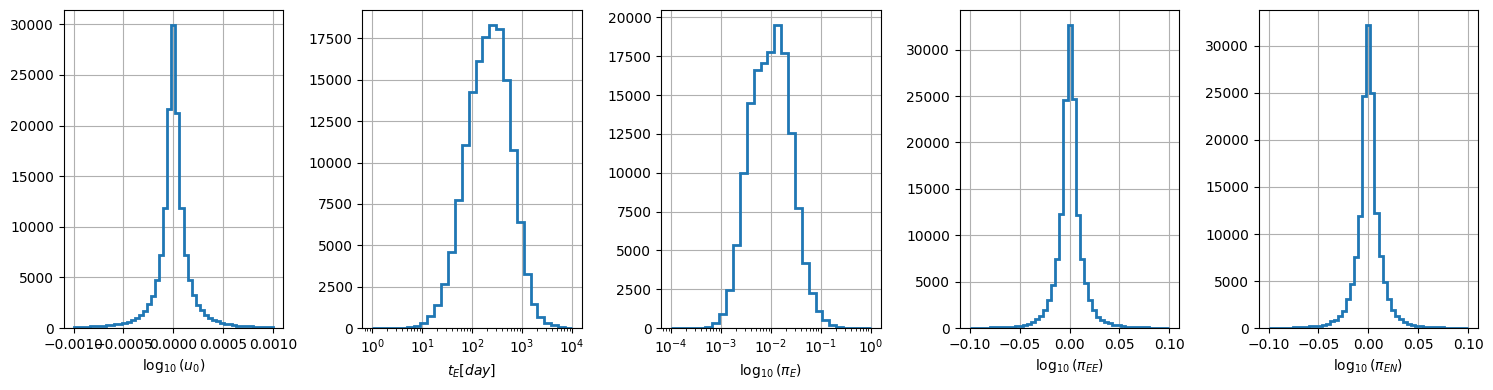

In [17]:


param_names = ['u0', 'tE', 'piE','piEE','piEN']
param_labels = [r'$\log_{10}(u_0)$', r'$t_E [day]$', r'$\log_{10}(\pi_E)$', r'$\log_{10}(\pi_{EE})$',r'$\log_{10}(\pi_{EN})$']

# Filter valid values (positive and finite)
# mask = np.all((true[param_names] > 0) & np.isfinite(true[param_names]), axis=1)
valid_data = true[param_names]
log_data = valid_data#np.log10(valid_data)

# Plot histograms
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, param in enumerate(param_names):
    if param=='tE':
        axes[i].hist(log_data[param], bins=np.logspace(0,4,30), histtype='step', linewidth=2)
        axes[i].set_xscale("log")
    elif param=='piE':
        axes[i].hist(log_data[param], bins=np.logspace(-4,0,30), histtype='step', linewidth=2)
        axes[i].set_xscale("log")
    elif param=='u0':
        axes[i].hist(log_data[param], bins=np.linspace(-1e-3,1e-3,50), histtype='step', linewidth=2)
    else: 
        axes[i].hist(log_data[param], bins=np.linspace(-1e-1,1e-1,50), histtype='step', linewidth=2)
    axes[i].set_xlabel(param_labels[i])
    # axes[i].set_ylabel('Count')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


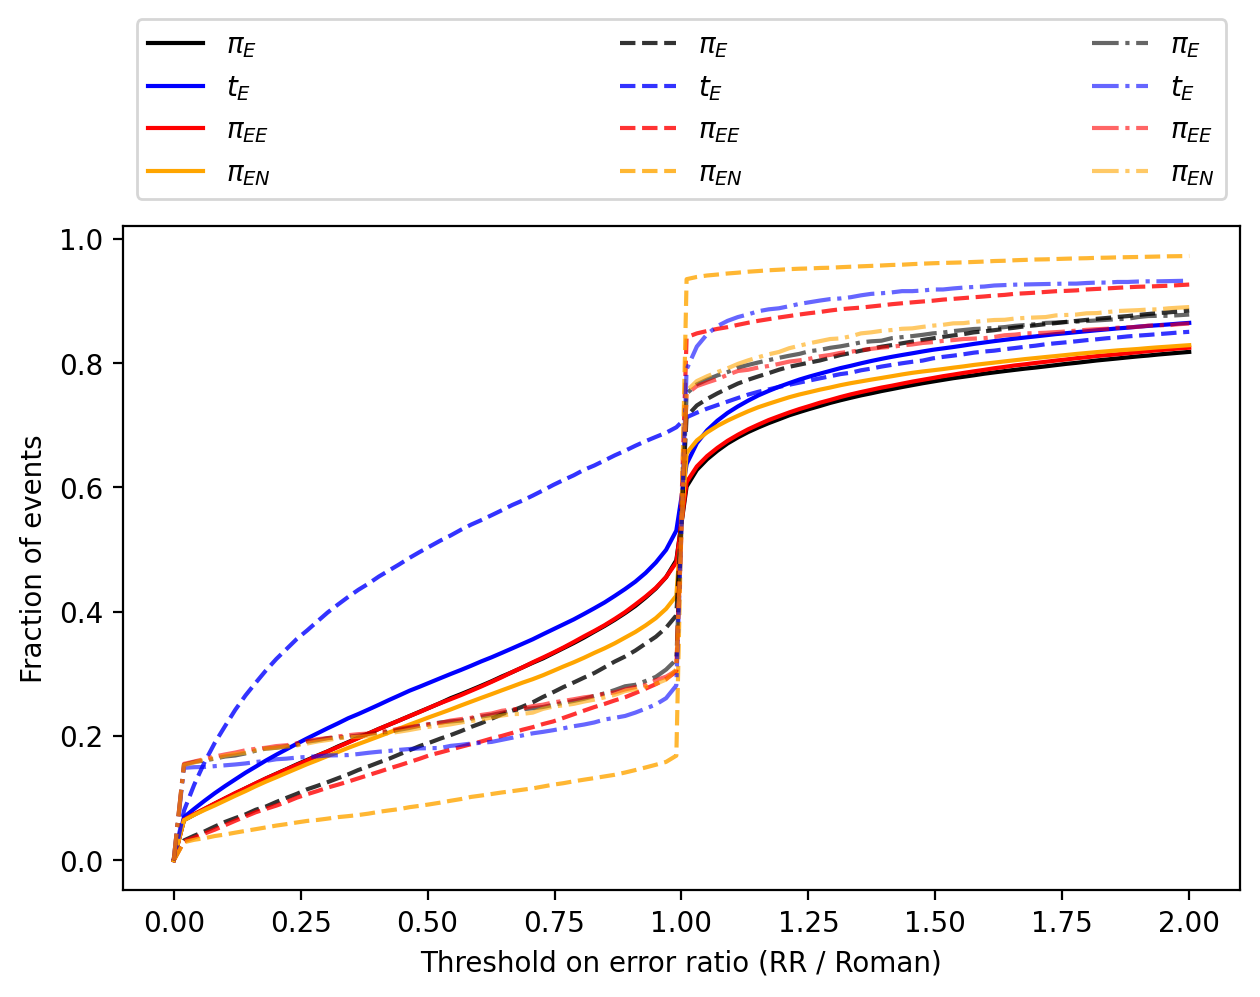

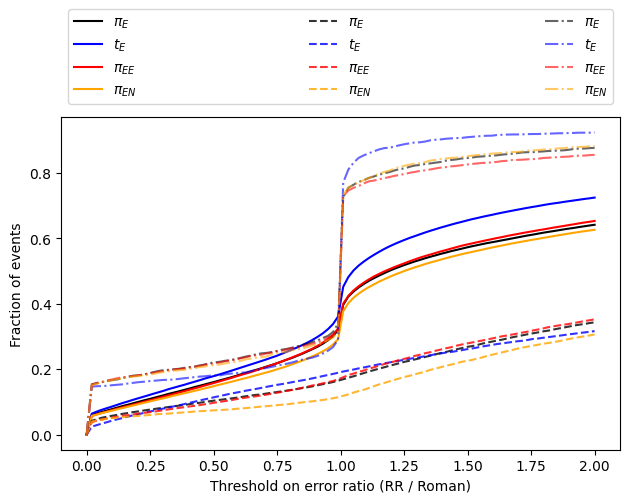

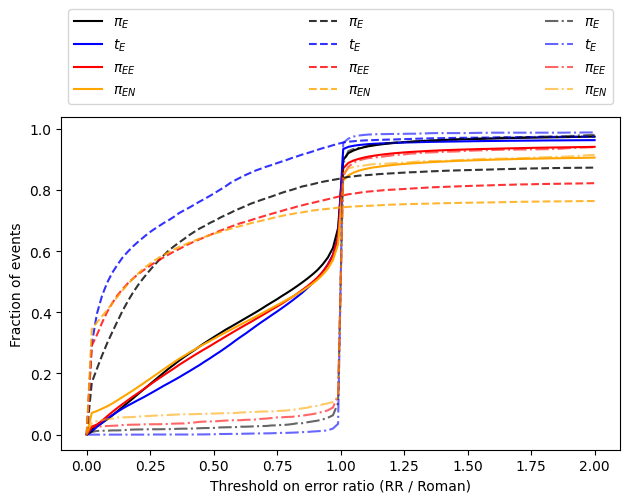

In [16]:
plt.figure(dpi=200)
label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}

CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
# model = 'PSPL'
for k,met in enumerate([[met_1_rr,met_1_roman],[met_2_rr,met_2_roman],[met_3_rr,met_3_roman]]):
    for i,cat in enumerate(["A","B","C"]):
        m_rr = met[0].merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')
        m_roman = met[1].merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')
        if i == 0:
            line = '-'
            alph=1
        elif i==1:
            line = '--'
            alph=0.8
        elif i==2:
            line = '-.'
            alph=0.6
            
        for j,p in enumerate(['piE','tE','piEE','piEN']):
            ratio = m_rr[p]/m_roman[p]
            fraction = []
            thresh = np.linspace(0,2,100)
            for alpha in thresh:
                fraction.append(len(ratio[ratio<alpha])/len(ratio))
    
            plt.plot(thresh,fraction,color = CLR[j],linestyle=line,label=label_dict[p],alpha=alph)
            plt.xlabel("Threshold on error ratio (RR / Roman)")
            plt.ylabel('Fraction of events')
    
    
    plt.legend(loc='best',ncols=3,mode="expand",bbox_to_anchor=(0, 1.02, 1, 0.2))
    plt.tight_layout()
    path_save_fig = '/home/anibal/figures_paper_romanrubin/'
    plt.savefig(path_save_fig+f'threshold_{label_met[k]}_{model}.png')
    plt.show()

In [9]:
def garwood_interval(N, cl=0.68):
    """
    Intervalos exactos de Poisson (Garwood) para nivel de confianza cl.
    Devuelve (low, high) para cada bin.
    """
    N = np.asarray(N, dtype=float)
    alpha = 1.0 - cl
    low = np.zeros_like(N)
    pos = N > 0
    low[pos] = 0.5 * chi2.ppf(alpha/2.0, 2.0*N[pos])
    high = 0.5 * chi2.ppf(1.0 - alpha/2.0, 2.0*(N + 1.0))
    return low, high

def poisson_errors_exact(counts, cl=0.68):
    """
    Calcula errores de Poisson exactos (asimétricos) para todos los bins.
    Retorna matriz (2, N) lista para yerr de matplotlib.errorbar.
    """
    counts = np.asarray(counts, dtype=float)
    low, high = garwood_interval(counts, cl=cl)
    yerr_minus = counts - low
    yerr_plus = high - counts
    return np.vstack([yerr_minus, yerr_plus])

# # Ejemplo: histograma con bins altos y bajos
# rng = np.random.default_rng(0)
# data = np.concatenate([
#     rng.normal(0, 1, 1000),  # alta estadística
#     rng.normal(5, 1, 10)     # baja estadística
# ])
# counts, bins = np.histogram(data, bins=20)
# centers = 0.5*(bins[1:] + bins[:-1])

# # Calcular errores exactos para todos los bins
# yerr = poisson_errors_exact(counts, cl=0.68)

# # Graficar
# plt.errorbar(centers, counts, yerr=yerr, fmt='o', capsize=3, label='Errores Poisson exactos (Garwood)')
# plt.bar(centers, counts, width=np.diff(bins), alpha=0.3, label='Histograma')
# plt.xlabel('Valor')
# plt.ylabel('Cuentas')
# plt.legend()
# plt.show()


In [11]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import chi2

# def garwood_interval(N, cl=0.68):
#     """Intervalos exactos de Poisson (Garwood) para nivel de confianza cl."""
#     N = np.asarray(N, dtype=float)
#     alpha = 1.0 - cl
#     low = np.zeros_like(N)
#     pos = N > 0
#     low[pos] = 0.5 * chi2.ppf(alpha/2.0, 2.0*N[pos])
#     high = 0.5 * chi2.ppf(1.0 - alpha/2.0, 2.0*(N + 1.0))
#     return low, high

# def hybrid_poisson_errors(counts, threshold=20, cl=0.68):
#     """
#     Devuelve errores para un histograma:
#     - N >= threshold: usa sqrt(N) simétrico
#     - N <  threshold: usa Garwood (asimétrico)
#     """
#     counts = np.asarray(counts, dtype=float)
#     yerr_minus = np.zeros_like(counts)
#     yerr_plus = np.zeros_like(counts)

#     # caso alto conteo
#     high_mask = counts >= threshold
#     yerr_minus[high_mask] = np.sqrt(counts[high_mask])
#     yerr_plus[high_mask]  = np.sqrt(counts[high_mask])

#     # caso bajo conteo
#     low_mask = counts < threshold
#     low_vals, high_vals = garwood_interval(counts[low_mask], cl=cl)
#     yerr_minus[low_mask] = counts[low_mask] - low_vals
#     yerr_plus[low_mask]  = high_vals - counts[low_mask]

#     return np.vstack([yerr_minus, yerr_plus])

# # Ejemplo: histograma con bins bajos y altos
# rng = np.random.default_rng(0)
# data = np.concatenate([
#     rng.normal(0, 1, 1000),  # alta estadística
#     rng.normal(5, 1, 10)     # baja estadística
# ])
# counts, bins = np.histogram(data, bins=20)
# centers = 0.5*(bins[1:] + bins[:-1])

# # Calcular errores híbridos
# yerr = hybrid_poisson_errors(counts, threshold=20, cl=0.68)

# # Graficar
# plt.errorbar(centers, counts, yerr=yerr, fmt='o', capsize=3, label='Errores híbridos')
# plt.bar(centers, counts, width=np.diff(bins), alpha=0.3, label='Histograma')
# plt.xlabel('Valor')
# plt.ylabel('Cuentas')
# plt.legend()
# plt.show()


In [12]:
# label_dict={'piE':r"$\pi_E$",
#             'tE':r"$t_E$",
#             'rho':r"$\rho$",
#             'piEE':r'$\pi_{EE}$',
#             'piEN':r'$\pi_{EN}$'}

# CLR = ['k','blue','r','orange','purple','green']
# label_met = ['met1','met2','met3']
# # model = 'PSPL'


# label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
#                  r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]

# dict_cat_peak = {"A":"peak in Rubin+Roman",
#                 "B":"peak in Rubin",
#                 "C":"peak in Roman"}
# dbins = 10
# time = np.arange(0,500+dbins,dbins)
# plt.figure(dpi=100)
# plt.hist(true['tE'],rwidth=0.8,bins = time)
# plt.xlabel(r"$t_E$")
# plt.show()
# for k,met in enumerate([[met_1_rr,met_1_roman],[met_2_rr,met_2_roman],[met_3_rr,met_3_roman]]):
#     plt.figure(dpi=200)
#     for i,cat in enumerate(["A","B","C"]):
        
#         fraction = []
#         fraction_err = []
#         for t_tresh in range(len(time)-1):
#             ti = time[t_tresh]
#             tf = time[t_tresh+1]
#             m_rr = met[0].merge(true[(true["peak_flag"]==cat)&(true["tE"]<tf)&(true["tE"]>ti)][['Source', 'Set']], on=['Source', 'Set'], how='inner')
#             m_roman = met[1].merge(true[(true["peak_flag"]==cat)&(true["tE"]<tf)&(true["tE"]>ti)][['Source', 'Set']], on=['Source', 'Set'], how='inner')
        
#             p = "piE"
#             ratio = m_rr[p] / m_roman[p]
            
#             A_counts = len(m_rr)
#             B_counts = len(m_roman)
        
#             # Errores exactos
#             lowA, highA = garwood_interval(np.array([A_counts]))
#             lowB, highB = garwood_interval(np.array([B_counts]))
#             errA_minus, errA_plus = A_counts - lowA[0], highA[0] - A_counts
#             errB_minus, errB_plus = B_counts - lowB[0], highB[0] - B_counts
        
#             if B_counts > 0:
#                 R = A_counts / B_counts
#                 # Propagación asimétrica
#                 R_low = (A_counts - errA_minus) / (B_counts + errB_plus)
#                 R_high = (A_counts + errA_plus) / (B_counts - errB_minus) if (B_counts - errB_minus) > 0 else np.nan
#                 errR_minus = R - R_low
#                 errR_plus = R_high - R
#             else:
#                 R = 0
#                 errR_minus = errR_plus = 0
        
#             if len(ratio) != 0:
#                 fraction.append(len(ratio[ratio < 1]) / len(ratio))
#                 fraction_err.append([errR_minus, errR_plus])
#             else:
#                 fraction.append(0)
#                 fraction_err.append([errR_minus, errR_plus])
        
#         # En el plot:
#         yerr = np.array(fraction_err).T  # matplotlib espera (2, N)
#         plt.errorbar(time[1:], fraction, yerr=yerr, fmt='.', capsize=3, label=dict_cat_peak[cat])

#         plt.xlabel(r"$t_E$ [days]")
#         plt.ylabel(f'Fraction of events with {label_rmet_lat[k]} <1')
    
#     plt.annotate('Fraction is computed in bins of 10 day', xy = (0.3,0.95),xycoords ='figure fraction')
#     plt.legend(loc='best',ncols=3,mode="expand",bbox_to_anchor=(0, 1.02, 1, 0.1))
#     plt.tight_layout()
#     # path_save_fig = '/home/anibal/figures_paper_romanrubin/'
#     # plt.savefig(path_save_fig+f'threshold_{label_met[k]}_{model}.png')
#     plt.show()

In [13]:
# plt.hist(met_3_rr['piE'][met_3_rr['piE']<0.25])
# plt.xlabel('$\sigma/\pi_E$')

In [10]:
# fit_rr[fit_rr['piE_err']<0.25*fit_rr['piE']]

In [16]:
# true.columns

In [17]:
# met_1_rr_filtered

In [18]:
# met_1_rr_filtered

In [129]:
true_filtered

,Source,Set,t0,u0,tE,piEN,piEE,Category,mass,sel_crit,...,z_lpeak,y_lpeak,W149_rpeak,u_rpeak,g_rpeak,r_rpeak,i_rpeak,z_rpeak,y_rpeak,flag_npeak_gt10
1,163,1,2.461723e+06,-0.000037,149.422153,0.001900,0.011029,None,47.934876,True,...,5,0,5736,0,0,0,0,0,0,1
3,143,1,2.461781e+06,-0.000004,699.381052,-0.033642,0.036408,None,34.655519,True,...,34,10,7008,0,72,142,185,136,7,1
4,91,1,2.461279e+06,-0.000056,340.035055,-0.022137,-0.003474,None,33.573026,True,...,5,0,6912,0,0,2,2,3,1,1
5,25,1,2.461228e+06,-0.000189,302.778601,0.004934,0.005431,None,58.645416,True,...,10,4,6912,1,5,8,12,13,2,1
6,114,1,2.463118e+06,-0.000001,356.444914,0.006847,-0.005798,None,87.005783,True,...,61,4,0,0,4,4,12,12,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151146,59401,4,2.463245e+06,-0.000027,649.709312,0.016230,0.019842,None,58.872278,True,...,8,0,0,0,0,0,4,42,0,1
151147,59402,4,2.461891e+06,0.000104,163.626084,0.004828,-0.003431,None,53.220684,True,...,1,0,0,0,0,2,25,16,0,1
151148,59383,4,2.462786e+06,-0.001074,353.445014,-0.000279,0.003855,None,60.607568,True,...,77,3,6912,4,70,66,135,97,4,1
151149,59394,4,2.461776e+06,-0.000008,493.959294,-0.009529,-0.002661,None,75.666219,True,...,0,0,7008,0,0,0,3,0,0,1


In [11]:
# true['flag_relevance']==True
df_mask = true[true['flag_npeak_gt10']==1][['Source','Set']]
met_1_rr_filtered = met_1_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_rr_filtered = met_2_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_rr_filtered = met_3_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_1_roman_filtered = met_1_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_roman_filtered = met_2_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_roman_filtered = met_3_roman.merge(df_mask, on=['Source', 'Set'], how='inner')

In [127]:
# met_1_rr_filtered.merge(true[true["peak_flag"]=="C"][["Source","Set"]], on=['Source', 'Set'], how='inner')
true.columns


Index(['Source', 'Set', 't0', 'u0', 'tE', 'piEN', 'piEE', 'Category', 'mass',
       'sel_crit', 'piE', 'W149', 'u', 'g', 'r', 'i', 'z', 'y', 'W149_peak',
       'u_peak', 'g_peak', 'r_peak', 'i_peak', 'z_peak', 'y_peak',
       'W149_npeak', 'u_npeak', 'g_npeak', 'r_npeak', 'i_npeak', 'z_npeak',
       'y_npeak', 'W149_lpeak', 'u_lpeak', 'g_lpeak', 'r_lpeak', 'i_lpeak',
       'z_lpeak', 'y_lpeak', 'W149_rpeak', 'u_rpeak', 'g_rpeak', 'r_rpeak',
       'i_rpeak', 'z_rpeak', 'y_rpeak', 'flag_npeak_gt10'],
      dtype='object')

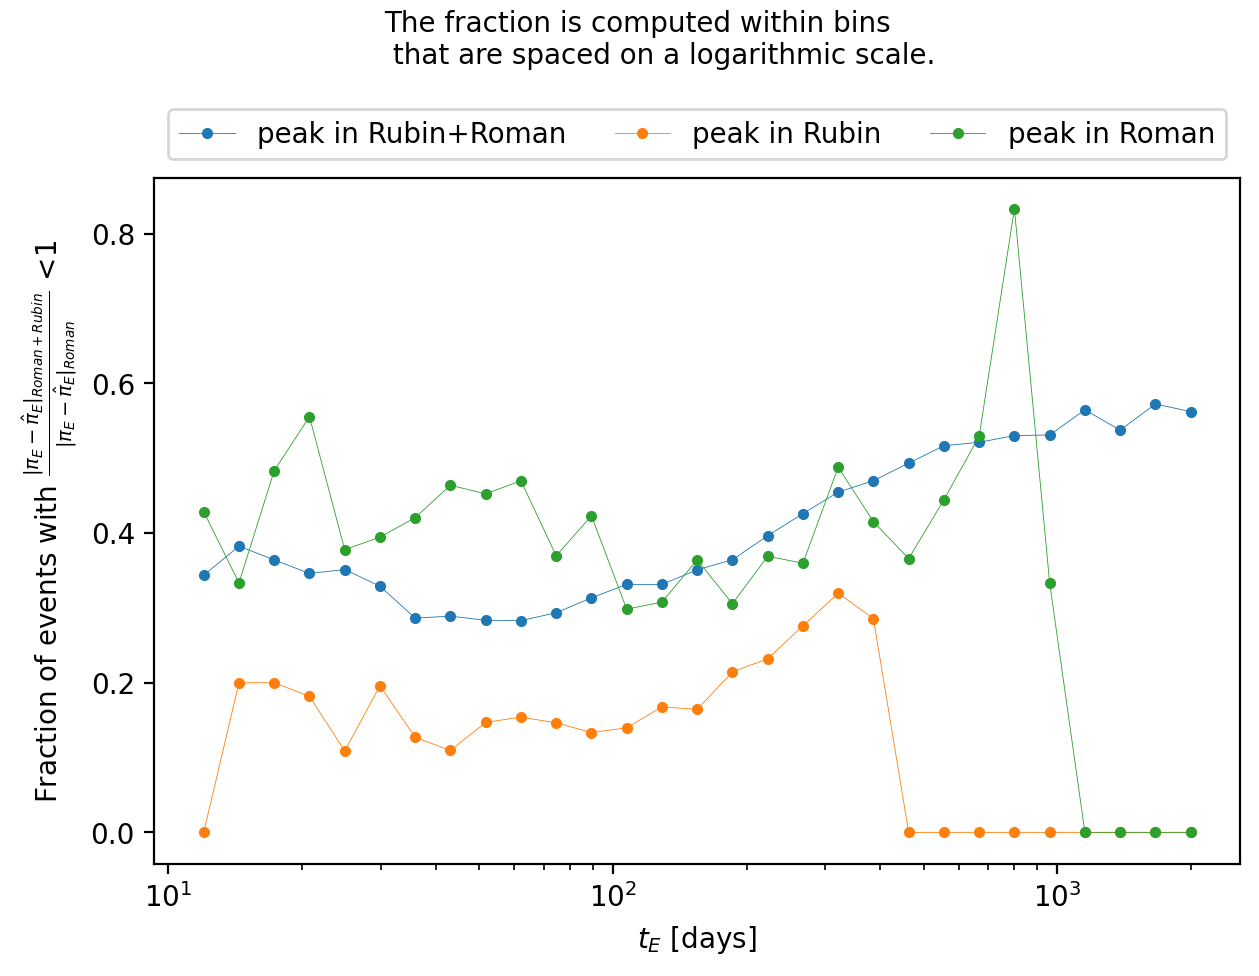

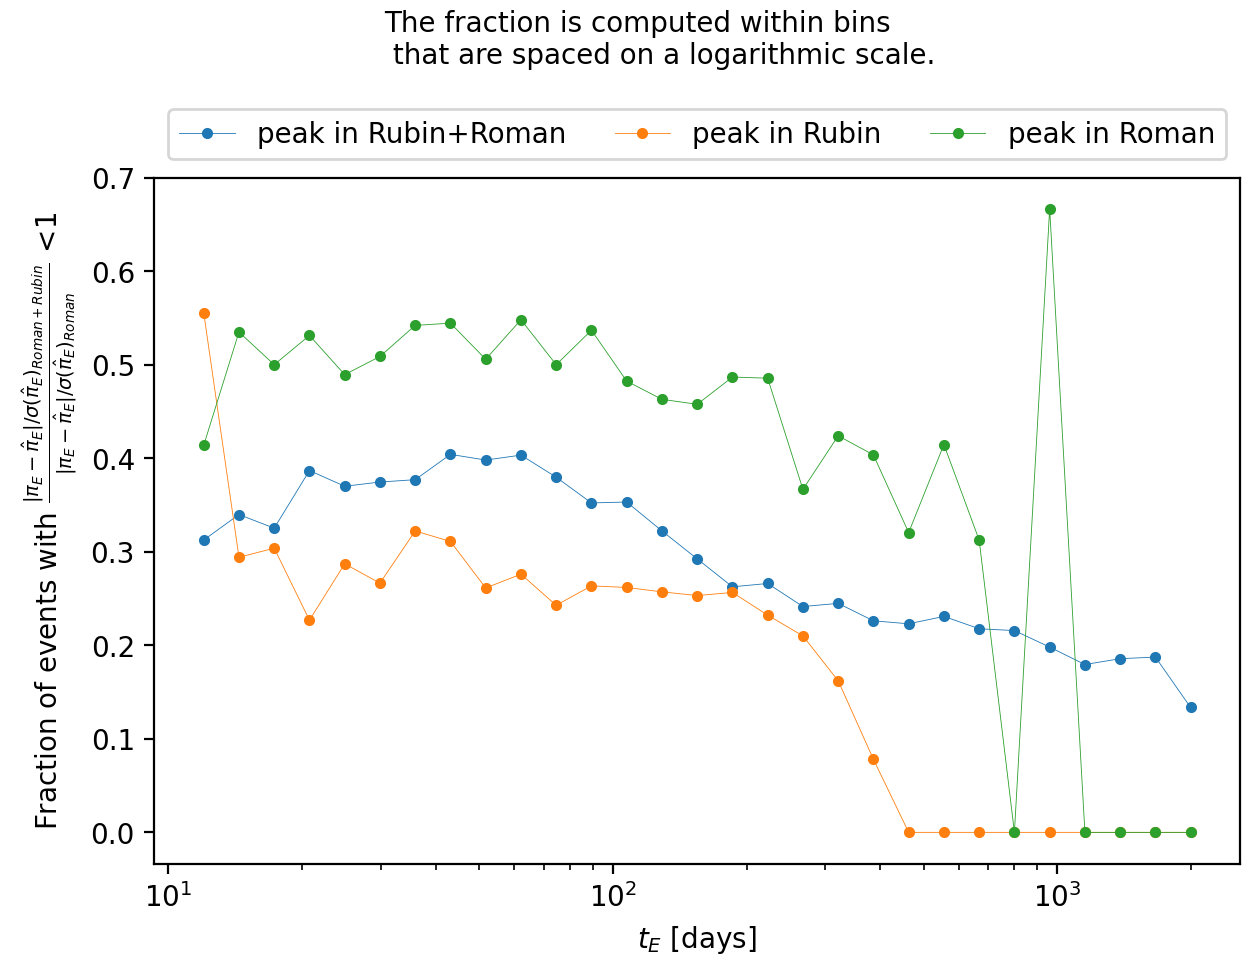

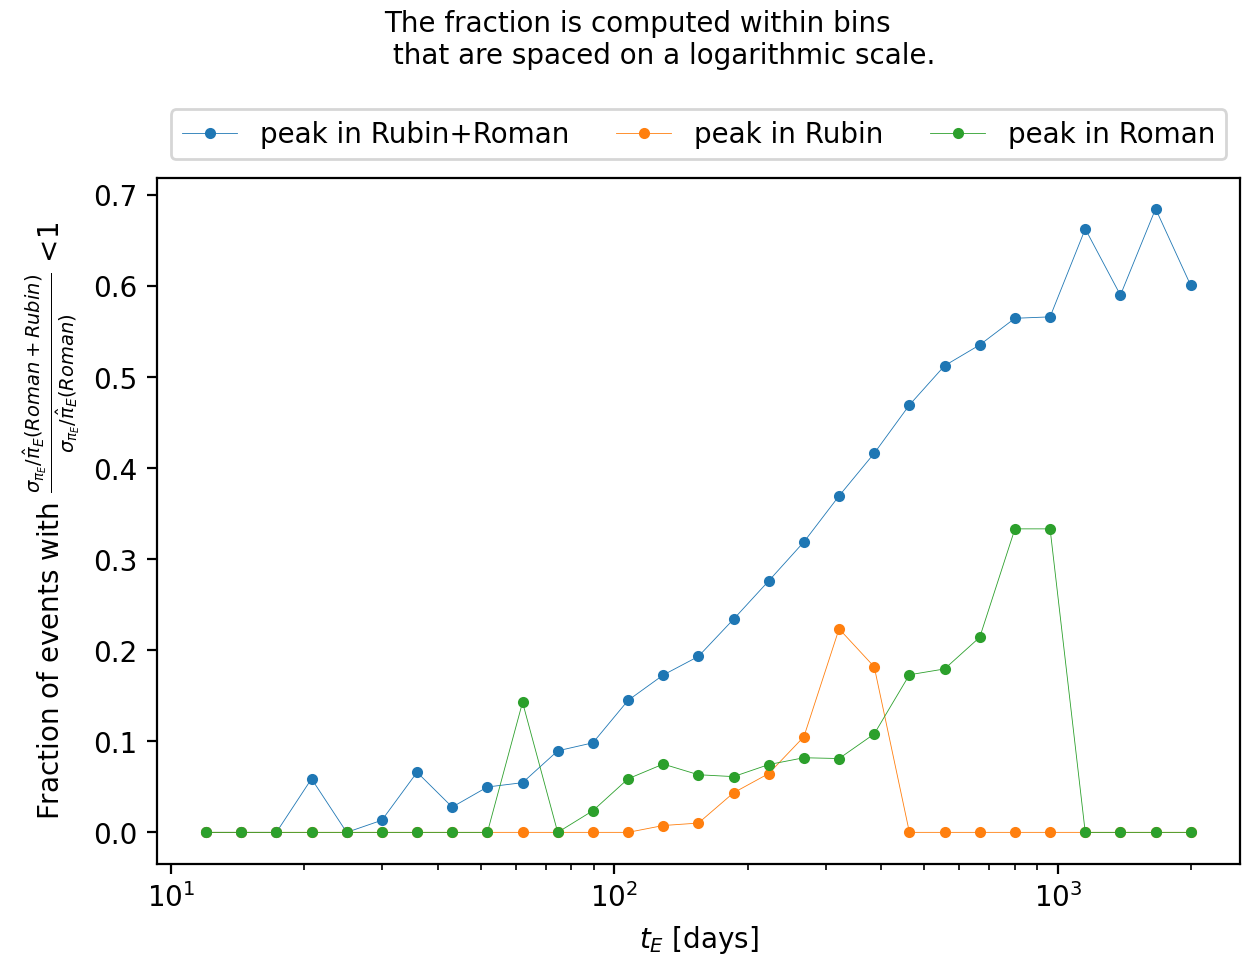

In [13]:
%matplotlib inline
label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}

CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
# model = 'PSPL'


label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
                 r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]

dict_cat_peak = {"A":"peak in Rubin+Roman",
                "B":"peak in Rubin",
                "C":"peak in Roman"}
dbins = 10
time = np.logspace(1,3.3,30)
# np.arange(0,1000+dbins,dbins)
# plt.figure(dpi=100)
# plt.hist(df_mask['tE'],rwidth=0.8,bins = time)
# plt.xlabel(r"$t_E$")
# plt.yscale("log")
# plt.xscale("log")
# plt.show()
for k,met in enumerate([[met_1_rr_filtered,met_1_roman_filtered],
                        [met_2_rr_filtered,met_2_roman_filtered],
                        [met_3_rr_filtered,met_3_roman_filtered]]):
    plt.figure(dpi=200)
    for i,cat in enumerate(["A","B","C"]):
        
        fraction = []
        fraction_err = []
        for t_tresh in range(len(time)-1):
            # print(t_tresh)
            ti = time[t_tresh]
            tf = time[t_tresh+1]
            # print(ti,tf)
            m_rr = met[0].merge(true[(true["peak_flag"]==cat)&(true["tE"]<tf)&(true["tE"]>ti)][['Source', 'Set']], on=['Source', 'Set'], how='inner')
            m_roman = met[1].merge(true[(true["peak_flag"]==cat)&(true["tE"]<tf)&(true["tE"]>ti)][['Source', 'Set']], on=['Source', 'Set'], how='inner')
            m_rr = m_rr[m_rr[p]<0.5]
            m_roman = m_roman.merge(m_rr[['Source', 'Set']], on=['Source', 'Set'], how='inner')
            # m_roman =
            # print(m_rr)
            # print(m_rr)
            if i == 0:
                line = '-'
                alph = 1
            elif i == 1:
                line = '--'
                alph = 0.8
            elif i == 2:
                line = '-.'
                alph = 0.6
            
            # for j,p in enumerate(['piE','piEE','piEN']):
            p = "piE"
            ratio = m_rr[p]/m_roman[p]
            
                
                # thresh = np.linspace(0,2,100)
                # for alpha in thresh:
            A_counts=len(m_rr)
            B_counts=len(m_roman)
            # sigma_A = np.sqrt(A_counts)
            # sigma_B = np.sqrt(B_counts)
            
            # # Cociente
            # R = A_counts / B_counts
            
            # # Error del cociente
            # sigma_R = R * np.sqrt((sigma_A / A_counts)**2 + (sigma_B / B_counts)**2)
            sigma_R =0
            if len(ratio)!=0:
                fraction.append(len(ratio[ratio<1])/len(ratio))
                fraction_err.append(sigma_R)
            else:
                fraction.append(0)
                fraction_err.append(sigma_R)
        # plt.hist(df_mask['tE'],rwidth=0.8,bins = time,alpha=0.25,density=True)
        plt.plot(time[1:],fraction,marker='.',linestyle='-',linewidth=0.3,label=dict_cat_peak[cat])#,color = CLR[j],linestyle=line,label=label_dict[p],alpha=alph)
        plt.xscale("log")
        plt.xlabel(r"$t_E$ [days]")
        plt.ylabel(f'Fraction of events with {label_rmet_lat[k]} <1')
    
    plt.annotate('The fraction is computed within bins\n that are spaced on a logarithmic scale.', xy = (0.3,0.95),xycoords ='figure fraction')
    plt.legend(loc='best',ncols=3,mode="expand",bbox_to_anchor=(0, 1.02, 1, 0.1))
    plt.tight_layout()
    # path_save_fig = '/home/anibal/figures_paper_romanrubin/'
    # plt.savefig(path_save_fig+f'threshold_{label_met[k]}_{model}.png')
    plt.show()

In [14]:
# Parámetros a considerar
if model=="PSPL":
    params = ["tE", "piE", "piEE", "piEN"]
elif model=="FSPL":
    params = ["tE", "piE","rho", "piEE", "piEN"]
# Función para calcular el ratio para cada par de dataframes
def compute_ratio(df_rr, df_roman, params):
    # Solo conservamos las columnas deseadas + Source y Set
    df_rr_sub = df_rr[["Source", "Set"] + params]
    df_roman_sub = df_roman[["Source", "Set"] + params]

    # Hacemos un merge por Source y Set para alinear las filas
    merged = df_rr_sub.merge(df_roman_sub, on=["Source", "Set"], suffixes=('_rr', '_roman'))

    # Calculamos los ratios
    ratio_df = merged[["Source", "Set"]].copy()
    for p in params:
        ratio_df[p] = merged[f"{p}_rr"] / merged[f"{p}_roman"]
    
    return ratio_df

# Aplicar la función a tus métricas
met1_ratio = compute_ratio(met_1_rr_filtered, met_1_roman_filtered, params)
met2_ratio = compute_ratio(met_2_rr_filtered, met_2_roman_filtered, params)
met3_ratio = compute_ratio(met_3_rr_filtered, met_3_roman_filtered, params)
met1_ratio

,Source,Set,tE,piE,piEE,piEN
0,163,1,1.354249,0.939343,0.864426,0.996241
1,143,1,0.026292,4.508154,2.361597,33.409434
2,91,1,0.550770,2.506003,2.656423,2.506894
3,25,1,0.047073,1.542749,0.039428,1.703168
4,114,1,1.484356,7.448249,0.888884,10.923211
...,...,...,...,...,...,...
119757,59401,4,0.620719,0.826278,0.909737,0.779323
119758,59402,4,0.437773,0.981914,0.521014,0.782575
119759,59383,4,0.831274,0.863995,0.480837,0.894541
119760,59394,4,0.999988,0.999979,0.999986,0.999980


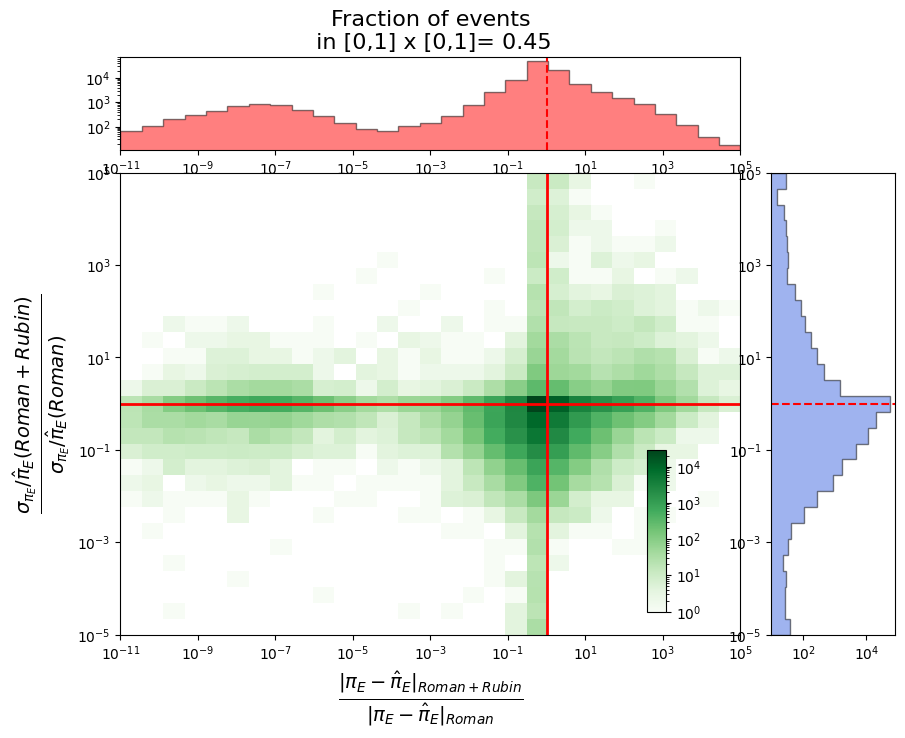

In [15]:

binsx = np.logspace(-11, 5, 30)
binsy = np.logspace(-5, 5, 30)
def create_hist2d_with_marginals(ax, x, y, labels, p,binsx,binsy, first_col=False):

    tex_label = {'t0':'t_0', 'u0':'u_0', 'tE':'t_E', 'piE':'\pi_{E}', 'piEN':'\pi_{EN}'}
    # Main scatter plot
    hb = ax.hist2d(x, y, bins=(binsx, binsy), cmap='Greens',norm=LogNorm())
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    # ax.set_xlim(1e-5, 1e5)
    # ax.set_ylim(1e-5, 1e5)

    # Create inset axes for the histograms
    ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
    ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)

    # Histogram settings
    binwidth = 0.1
    ax_histx.hist(x, bins=binsx, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='red')
    ax_histy.hist(y, bins=binsy, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='royalblue', orientation='horizontal')
    ax_histx.set_yscale("log")
    ax_histy.set_yscale("log")
    ax_histx.set_xscale("log")
    ax_histy.set_xscale("log")

    # Remove ticks from inset histograms
    # ax_histx.tick_params(axis="x", labelbottom=False)
    # ax_histx.tick_params(axis="y", left=False, labelleft=False)
    # ax_histy.tick_params(axis="y", labelleft=False)
    # ax_histy.tick_params(axis="x", bottom=False, labelbottom=False)
    # ax_histy.set_yscale("log")
    # Add vertical and horizontal lines
    ax_histx.axvline(1, color='red', ls='--')
    ax_histy.axhline(1, color='red', ls='--')
    ax.axvline(1, ymin=0, ymax=1, lw=2, color='red')
    ax.axvline(0, ymin=0, ymax=1, lw=2, color='red')
    ax.axhline(0, xmin=0, xmax=1, lw=2, color='red')
    ax.axhline(1, xmin=0, xmax=1, lw=2, color='red')

    # Set labels with LaTeX formatting
    # label_m1 = lambda p: r'$\frac{|' + f'{labels[p]}' + r'^{true}-' + f'{labels[p]}' + r'^{fit}|_{RR}}{|' + f'{labels[p]}' + r'^{true}-' + f'{labels[p]}' + r'^{fit}|_{R}}$'
    # label_m2 = r'$\frac{\sigma_{RR}}{\sigma_{Roman}}$'
    labelx, labely =labels[0],labels[1]
    ax.set_xlabel(labelx, fontsize=20)
    
    # ax.set_xlabel("a",fontsize=20)
    # if first_col:
    ax.set_ylabel(labely, fontsize=20)

    # Add a colorbar inside the main plot
    cax = ax.inset_axes([0.85, 0.05, 0.03, 0.35], transform=ax.transAxes)
    cbar = plt.colorbar(hb[3], cax=cax, orientation='vertical')
    # cax.set_yticks([0, 50, 1000])
    # cax.set_yticklabels([0, 100, 2000], fontsize=8)
    x_min=0
    x_max=1
    y_min=0
    y_max=1
    fil_x= x[(y<1)&(y>0)]
    filtered=fil_x[(fil_x<1)&(fil_x>0)]

    number_in_square = len(filtered)/len(y)
    text = f"Fraction of events\n in [{x_min},{x_max}] x [{y_min},{y_max}]= {round(number_in_square ,2)}"  # Insert the number here
    ax.set_title(text, fontsize = 16)

# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'A'
p = 'piE'
x3 = met1_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
y3 = met3_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
# print(x3)

# create_hist2d_with_marginals(axes[0], x, y, ["BIAS_ratio","ERR_ratio"], 'te', first_col=True)
# create_hist2d_with_marginals(axes[1], x2, y2, ["BIAS_ratio","ERR_ratio"], 'rho')
lab_piE = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$",r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
lab_rho = [r"$\frac{|\rho - \hat{\rho}|_{Roman+Rubin}}{|\rho - \hat{\rho}|_{Roman}}$",r"$\frac{\sigma_{\rho}/\hat{\rho}(Roman+Rubin)}{\sigma_{\rho}/\hat{\rho}(Roman)}$"]
create_hist2d_with_marginals(axes, x3, y3, lab_piE, p,binsx,binsy)

# plt.tight_layout()
plt.show()

In [88]:
def create_scatter_with_marginals(ax, x1, x2, y, labels, p, binsx, binsy, first_col=False):

    tex_label = {'t0':'t_0', 'u0':'u_0', 'tE':'t_E', 'piE':'\pi_{E}', 'piEN':'\pi_{EN}'}
    # Main scatter plot
    hb = ax.scatter(x1, y,alpha=0.5,label='Roman+Rubin')
    h2 = ax.scatter(x2, y,alpha=0.5,label='Roman')
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Create inset axes for the histograms
    ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
    ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)

    # Histogram settings
    binwidth = 0.1
    ax_histx.hist(x1, bins=binsx, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='red',label='Roman+Rubin')
    ax_histx.hist(x2, bins=binsx, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='green',label="Roman")
    ax_histy.hist(y, bins=binsy, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='royalblue', orientation='horizontal')
    ax_histx.set_yscale("log")
    ax_histy.set_yscale("log")
    ax_histx.set_xscale("log")
    ax_histy.set_xscale("log")

    ax_histx.tick_params(axis = "x", labelbottom=False)
    ax_histy.tick_params(axis = "y", labelleft=False)
    ax_histx.axvline(0.5, color = 'red', ls='--',lw = 2)
    ax_histy.axhline(1, color = 'red', ls='--',lw = 2)
    ax.axvline(0.5, ymin = 0, ymax = 1, ls = '--', lw = 2, color = 'red')
    ax.axhline(1, xmin = 0, xmax = 1, ls = '--',lw = 2, color = 'red')
    labelx, labely =labels[0],labels[1]
    ax.set_xlabel(labelx, fontsize=20)
    ax.set_ylabel(labely, fontsize=20)
    x_min=0
    x_max=0.5
    y_min=0
    y_max=1
    fil_x1= x1[(y<1)&(y>0)]
    filtered1=fil_x1[(fil_x1<0.5)&(fil_x1>0)]
    number_in_square1 = len(filtered1)/len(y)
    text1 = f"Fraction of Roman+Rubin events\n in [{x_min},{x_max}] x [{y_min},{y_max}]= {round(number_in_square1 ,2)}"  # Insert the number here

    fil_x2= x2[(y<1)&(y>0)]
    filtered2=fil_x2[(fil_x2<0.5)&(fil_x2>0)]
    number_in_square2 = len(filtered2)/len(y)
    text2 = f"Fraction of Roman events\n in [{x_min},{x_max}] x [{y_min},{y_max}]= {round(number_in_square2 ,2)}"  # Insert the number here
    
    
    ax.set_title(text1+"\n"+text2, fontsize = 16)
    ax.set_ylim(1e-10,1e+4)
    ax.legend(loc='best')
    ax_histx.legend(loc='best')

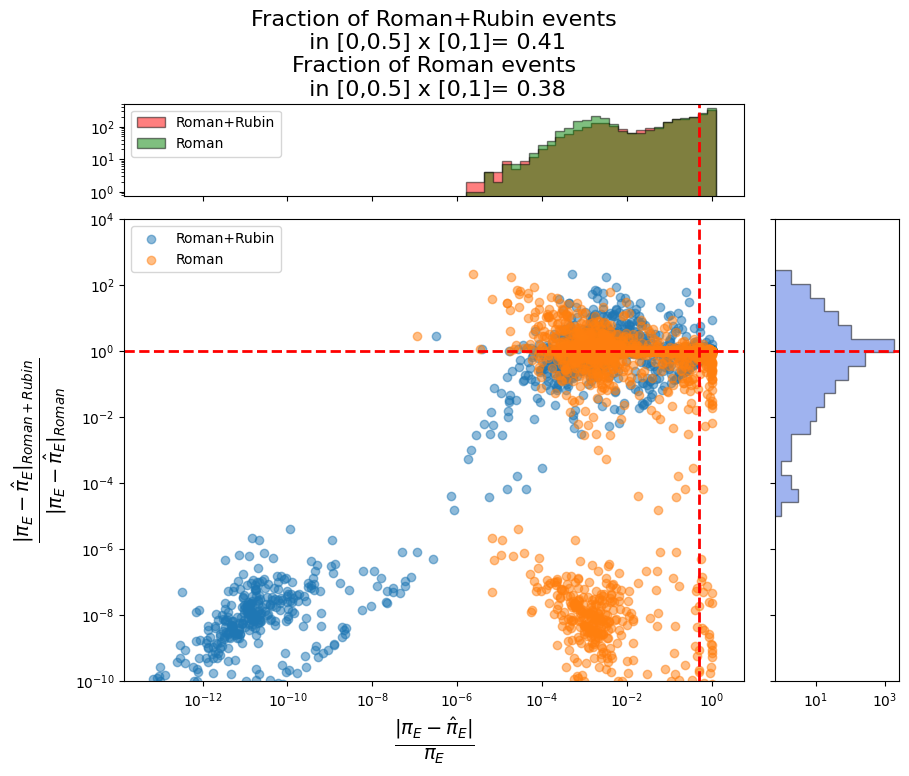

In [92]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'C'
binsx = np.logspace(-6, 0.1, 30)
binsy = np.logspace(-5, 7, 30)
p ='piE'
y = met1_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x1 = met_1_rr_filtered.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x2 = met_1_roman_filtered.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
# print(len(x3), len(y3),len(z3))
# print(x3)

# create_hist2d_with_marginals(axes[0], x, y, ["BIAS_ratio","ERR_ratio"], 'te', first_col=True)
# create_hist2d_with_marginals(axes[1], x2, y2, ["BIAS_ratio","ERR_ratio"], 'rho')
create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\pi_E}$",r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$"], 'piE',binsx,binsy)

# plt.tight_layout()
plt.show()

105605


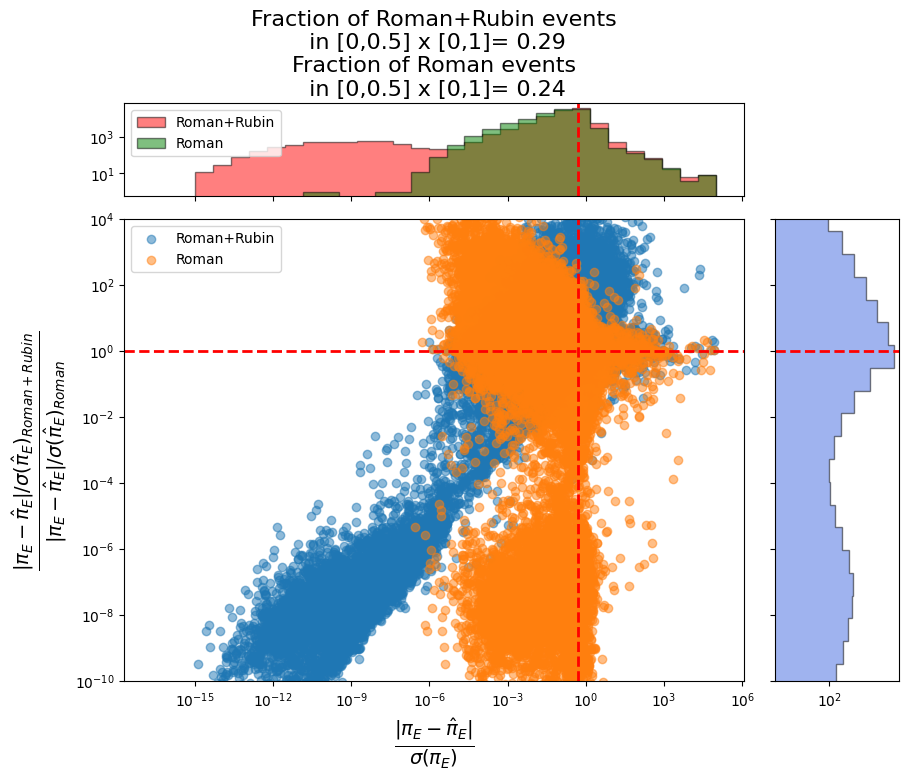

In [94]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'A'
binsx = np.logspace(-15, 5, 30)
binsy = np.logspace(-15, 5, 30)
y = met2_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_2_rr_filtered.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_2_roman_filtered.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
print(len(x1))

# create_hist2d_with_marginals(axes[0], x, y, ["BIAS_ratio","ERR_ratio"], 'te', first_col=True)
# create_hist2d_with_marginals(axes[1], x2, y2, ["BIAS_ratio","ERR_ratio"], 'rho')
create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\sigma(\pi_E)}$",r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$"], 'piE',binsx,binsy)

# plt.tight_layout()
plt.show()

105605


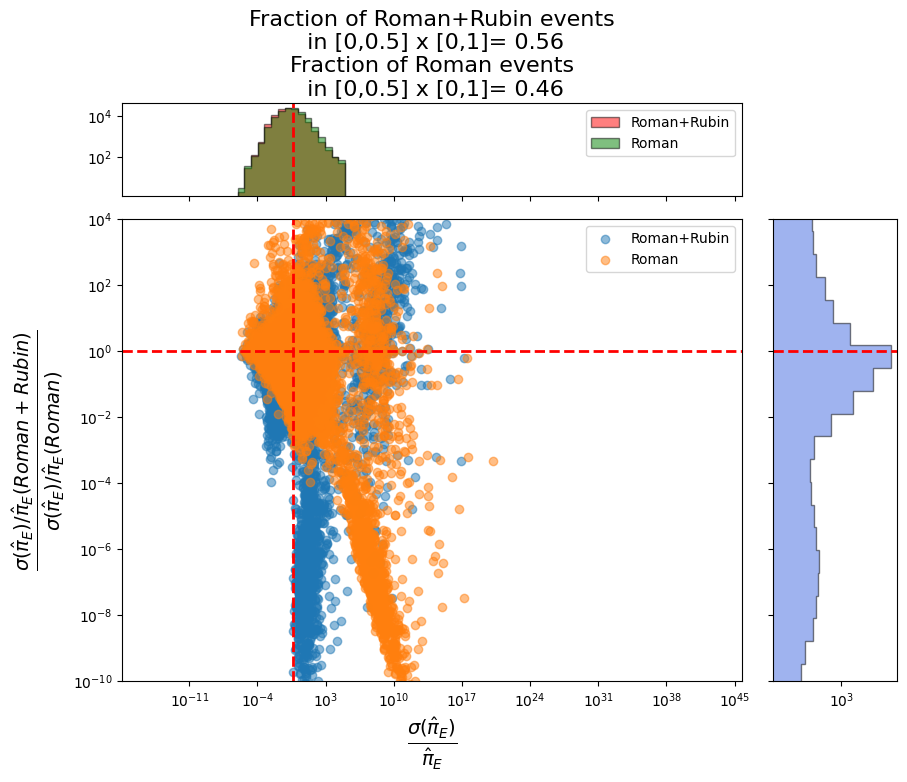

In [96]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'A'
binsx = np.logspace(-15, 5, 30)
binsy = np.logspace(-15, 5, 30)
y = met3_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_3_rr_filtered.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_3_roman_filtered.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
print(len(x1))

# create_hist2d_with_marginals(axes[0], x, y, ["BIAS_ratio","ERR_ratio"], 'te', first_col=True)
# create_hist2d_with_marginals(axes[1], x2, y2, ["BIAS_ratio","ERR_ratio"], 'rho')
create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{\sigma(\hat{\pi}_E)}{\hat{\pi}_E}$",r"$\frac{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman+Rubin)}{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman)}$"], 'piE',binsx,binsy)

# plt.tight_layout()
plt.show()

In [48]:
%matplotlib inline
plt.close("all")
def plot_histogram(ax, data, p, colors, some_flag=False):
    # print(data)
    sources = data['Source'].values
    data = data[p]   
    lab_latex = {'te':'tE(days)','rho':'\\rho' ,'piE':'\pi_E','q':'q'}
    data_label = lab_latex[p]
    lab_latex_legend = {'te':'t_E','rho':'\\rho','piE':'\pi_E','q':'q'}
    xlabel=r'$log_{10}'+f"[{lab_latex[p]}]$"
    
    masks_rr = lambda p, label: [
        (met_1_rr[p][met_1_rr['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_rr[p][met_2_rr['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_rr[p][met_3_rr['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    masks_roman = lambda p, label:[
        (met_1_roman[p][met_1_roman['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_roman[p][met_2_roman['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_roman[p][met_3_roman['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    
    if some_flag:
        masks = masks_roman(p,lab_latex_legend[p])
        dataset = 'Roman'
        met_1 = met_1_roman[met_1_roman['Source'].isin(sources)]
        met_2 = met_2_roman[met_2_roman['Source'].isin(sources)]
        met_3 = met_3_roman[met_3_roman['Source'].isin(sources)]
    else:
        masks = masks_rr(p,lab_latex_legend[p])
        dataset = 'Roman and Rubin'
        met_1 = met_1_rr[met_1_rr['Source'].isin(sources)]
        met_2 = met_2_rr[met_2_rr['Source'].isin(sources)]
        met_3 = met_3_rr[met_3_rr['Source'].isin(sources)]

    # Plot the histogram of the true values
    ax.hist(np.log10(data), bins=30, color='royalblue', alpha=0.5, label=f'True value of ${lab_latex_legend[p]}$')
    
    # Iterate over the masks and plot the masked data
    for (mask, color, label) in masks:
        # Select the masked data based on the condition in the mask
        # print(label)
        masked_data = data[mask]
        ax.hist(np.log10(masked_data), 
                bins=30, histtype='step', color=color, lw=2, label=label)
    
    # Set labels and title
    # print(xlabel)
    ax.set_xlabel(xlabel, fontsize=20)
    

    ax.set_title('Percentage of events with:\n'+
                 f"$\\alpha({lab_latex_legend[p]})<0.25: $"+
                 f"{round(100*len(met_1[p][met_1[p]<0.25])/len(data),2)}%, "+'\n'+
                 f"$\\beta({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_2[p][met_2[p]<0.25])/len(data),1)}%, "+'\n'+
                 f"$\\gamma({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_3[p][met_3[p]<0.25])/len(data),2)}%",fontsize=15)
    
    ax.legend(fontsize=10)
    # ax.set_xticks([1,2,3,4],fontsize=12)
    
    ax.grid()
    

In [20]:
labelsparams = lambda p: labels[p]

label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'
# cats_label = {'A':'Overlap of the Observing Seasons of Roman and Rubin', 'B':'Rubin Season and Roman Gap', 'C':'Roman Season and Rubin Gap', 'D':'Roman Gap and Rubin gap'}

# cats_labels = {'A': 'Overlap seasons Roman and Rubin', 'B': 'Roman gap and Rubin season','C': 'gap Roman and gap Rubin', 'D': 'Season Roman and gap Rubin'}
# Function to plot histograms and annotations
def plot_histogram(ax, data1, data2, xlabel, title, limit):
    # ax.set_title(title)
    ax.hist(data1, bins=np.arange(0, 1.1, 0.1), edgecolor="k",lw=0.2, alpha=0.4, label='Roman+Rubin')
    ax.hist(data2, bins=np.arange(0, 1.1, 0.1), edgecolor="k",lw=0.2, alpha=0.4, label='Roman')
    ax.set_xlabel(xlabel, fontsize=20)
    # limit = 0.1
    ax.axvline(limit, color='red', linestyle='--')
    ax.legend(loc='best')
    
    fraction_data1 = len(data1[data1 < limit]) / len(data1)
    fraction_data2 = len(data2[data2 < limit]) / len(data2)
    
    ax.annotate(f'Fraction of events Roman+Rubin\nwith {xlabel}<{str(limit)} = {fraction_data1:.2f}', 
                xy=(0.5, -0.3), xycoords='axes fraction',
                ha='center', va='center', fontsize=15)
    ax.annotate(f'Fraction of events Roman\nwith {xlabel}<{str(limit)} = {fraction_data2:.2f}', 
                xy=(0.5, -0.45), xycoords='axes fraction',
                ha='center', va='center', fontsize=15)


In [ ]:
df1 = true[["Source","Set","mass"]]
df2 = fit_rr[["Source","Set","mass_v1","mass_v2","err_mass_v2","err_mass_v1"]]
mass_df = df1.merge(df2, on=["Source", "Set"], how="inner")

# Calculamos métricas entre columnas específicas
mass_df["met1_v1"] = abs(mass_df["mass"] - mass_df["mass_v1"])/mass_df["mass"]
mass_df["met2_v1"] = abs(mass_df["mass"] - mass_df["mass_v1"])/mass_df["err_mass_v1"]
mass_df["met3_v1"] = mass_df["err_mass_v1"]/mass_df["mass_v1"]

mass_df["met1_v2"] = abs(mass_df["mass"] - mass_df["mass_v2"])/mass_df["mass"]
mass_df["met2_v2"] = abs(mass_df["mass"] - mass_df["mass_v2"])/mass_df["err_mass_v2"]
mass_df["met3_v2"] = mass_df["err_mass_v2"]/mass_df["mass_v2"]

# print(mass_df[["Source", "Set", "met1_v1","met2_v1","met3_v1","met1_v2","met2_v2","met3_v2"]])

plt.hist(mass_df['met1_v1'],np.logspace(-15,37,40),rwidth=0.9)
plt.hist(mass_df['met1_v2'],np.logspace(-15,37,40),histtype='step',linewidth=3)
plt.yscale("log")
plt.xscale("log")
plt.show()
         
Binsx = np.logspace(0,2,30)
Binsy = np.logspace(-15,20,30)
plt.hist2d(true['mass'],mass_df['met1_v1'],bins=(Binsx, Binsy),label= 'True mass',norm=LogNorm())
plt.xlabel("mass")
plt.xlabel(r"$M$")
plt.ylabel(r"$|M-\hat{M}_L|/M$")
plt.yscale('log')
plt.xscale('log')
plt.colorbar()
plt.show()

plt.hist(true['mass'],bins=np.logspace(1,3,30),label= 'True mass')
plt.hist(fit_rr['mass_v2'],bins=np.logspace(1,3,30),label= 'True mass')
plt.hist(fit_rr['mass_v1'],bins=np.logspace(1,3,30),histtype='step',linewidth=3,label= 'True mass')
plt.legend(loc='best')
plt.show()

In [21]:
# x3 = met1_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
# y3 = met3_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']

In [62]:
cat = "B"
m1r = met1_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')
m3r = met3_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')

# display(m1r[])
# display(m3r)
p = 'piE'
df_filt = m1r.merge(m3r[m3r[p]<0.9][["Source", "Set"]], on=['Source', 'Set'], how='inner')
df_filt[df_filt[p]<0.9]

,Source,Set,tE,piE,rho,piEE,piEN
0,23,1,0.000062,0.000003,0.000158,0.000002,0.000143
2,65711,1,0.038837,0.000198,0.056978,0.000479,0.000408
3,228,1,0.010568,0.805705,23.728472,0.999382,2.189561
4,65617,1,0.058133,0.683196,0.665515,1.385210,1.210261
5,32845,1,0.018010,0.000364,0.698109,0.000239,0.000221
...,...,...,...,...,...,...,...
4685,65317,3,0.003972,0.646565,2.513509,1.044997,6.941940
4687,32578,3,0.058826,0.103893,1.000000,1.000000,0.046457
4689,32648,3,0.023504,0.857427,0.349418,0.843189,0.999433
4691,32717,3,0.367205,0.522682,1.000036,1.147490,63.357915


In [156]:
cat= 'C'
binsx = np.logspace(-15, 5, 30)
binsy = np.logspace(-15, 5, 30)
y = met1_ratio.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')#['piE']
x1 = met_1_rr.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')#['piE']
x2 = met_1_roman.merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')#['piE']

df_filt = y[y['piE']<1]

df_filt.merge(x1[x1['piE']>0.5][['Source', 'Set']], on=['Source', 'Set'], how='inner')

df_filt.merge(x2[x2['piE']>0.5][['Source', 'Set']], on=['Source', 'Set'], how='inner')

,Source,Set,tE,piE,rho,piEE,piEN
0,65672,1,1.000062,0.996044,1.000000,0.999394,0.995735
1,33204,1,1.000016,1.000000,1.000000,1.000000,1.000003
2,33375,1,1.057718,0.297688,1.000018,1.000000,1.362821
3,973,1,0.843094,0.433932,2.403856,0.154378,0.434598
4,33848,1,0.980268,0.213287,0.998344,0.211938,0.455051
...,...,...,...,...,...,...,...
548,31787,3,0.999997,1.000000,1.000009,1.000000,1.000000
549,31850,3,1.000003,0.999957,1.000000,1.000000,0.999948
550,31882,3,0.099487,0.016219,0.995000,0.002245,0.122503
551,32144,3,0.991092,0.999836,1.000202,0.999993,0.999804


In [100]:
# params
true[(true['flag_relevance']==True)&(true['peak_flag']=="C")]

,Source,Set,t0,u0,tE,piEN,piEE,Category,mass,sel_crit,...,y_lpeak,W149_rpeak,u_rpeak,g_rpeak,r_rpeak,i_rpeak,z_rpeak,y_rpeak,peak_flag,flag_relevance
69,22,1,2.461642e+06,0.001029,8.234421,0.000521,-0.000326,None,48.686425,True,...,0,790,0,0,0,0,0,0,C,True
219,302,1,2.461411e+06,0.000051,228.807859,-0.001912,-0.006941,None,82.679192,True,...,0,7547,0,0,0,0,0,0,C,True
240,336,1,2.461823e+06,-0.000153,65.529260,0.002031,-0.001266,None,89.760461,True,...,0,5964,0,0,0,0,0,0,C,True
312,446,1,2.462823e+06,-0.000097,298.592763,-0.000443,0.011371,None,41.993126,True,...,0,6912,0,0,0,0,0,0,C,True
314,437,1,2.462822e+06,0.000057,149.504156,-0.008118,-0.001392,None,40.811141,True,...,0,6086,0,0,0,0,0,0,C,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150968,59158,4,2.461815e+06,0.000411,43.149817,0.001201,0.000878,None,54.812397,True,...,0,4143,0,0,0,0,0,0,C,True
150991,59202,4,2.461818e+06,-0.000229,69.039008,-0.003837,0.002041,None,27.198094,True,...,0,6526,0,0,0,0,0,0,C,True
151010,59221,4,2.461449e+06,0.000207,157.194237,0.001126,0.002826,None,77.425725,True,...,0,6773,0,0,0,0,0,0,C,True
151084,59311,4,2.461432e+06,-0.000087,160.703459,0.004007,0.000827,None,44.030949,True,...,0,6912,0,0,0,0,0,0,C,True


In [35]:
# Keep one row per (Source, Set); adjust if you expect duplicates
rr = (met_3_rr.loc[met_3_rr['piE'] < 0.5, ['Source','Set','piE']]
               .drop_duplicates(['Source','Set'])
               .rename(columns={'piE':'piE_rr'}))

roman = (met_3_roman[['Source','Set','piE']]
                   .drop_duplicates(['Source','Set'])
                   .rename(columns={'piE':'piE_roman'}))

cmp = rr.merge(roman, on=['Source','Set'], how='inner')
result = cmp[cmp['piE_rr'] > cmp['piE_roman']]
# result has Source, Set, piE_rr, piE_roman for matched rows
result

,Source,Set,piE_rr,piE_roman
16,27,1,0.004801,0.004675
25,111,1,0.036288,0.036099
39,42,1,0.104995,0.102446
55,153,1,0.152674,0.150879
58,178,1,0.029317,0.028489
...,...,...,...,...
69072,59321,4,0.171072,0.170900
69087,59362,4,0.056997,0.056726
69098,59393,4,0.180569,0.158562
69101,59399,4,0.169946,0.169268


  0%|          | 0/1 [00:00<?, ?it/s]

done
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope u: SUCCESS


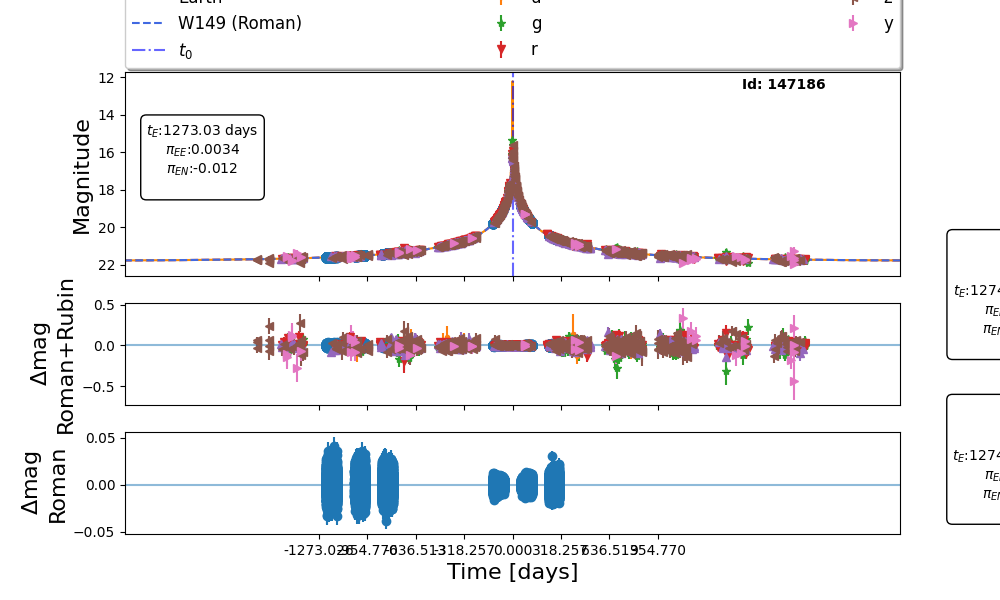

In [72]:

ssh = ssh_che()
#120
sources_array = [147186]
category = model

# download_data(sources, category)
nset = 1
# system_type = 'Planets_systems'
system_type = 'BH'
path_run = f'/share/storage3/rubin/microlensing/romanrubin/RR2025/July_set/{system_type}/'
path_save = f'/home/anibal/lightcurves/{system_type}_{nset}/'
if not os.path.exists(path_save):
    os.makedirs(path_save, exist_ok=True)
if not os.path.exists(path_save+f'Event_{sources_array[0]}.h5')==True:
    download_data(ssh,sources_array, nset, path_run, path_save)
else:
    print('The file already exist')


df_to_plot = create_df_to_plot(sources_array, category, path_save)
%matplotlib ipympl
# %matplotlib inline
plt.close('all')

fig, axes = graph_maker_1plot(df_to_plot, category, True)
info, params, curves  = read_data(df_to_plot['path_event'].iloc[0])

# axes[0].axvline(params['t0'])
# axes[0].axvspan(params['t_center']-1*params['tE']*np.sqrt(params['mass_ratio']),
#                 params['t_center']+1*params['tE']*np.sqrt(params['mass_ratio']),
#                 alpha=0.15,
#                 color='blue',label="t_{c}\pm t_{Ep}")

# axes[0].axvspan(params['t_center']-5*params['tE']*np.sqrt(params['rho']),params['t_center']+5*params['tE']*np.sqrt(params['rho']),alpha=0.25,color='red')
# plt.tight_layout()
plt.show()